### Data Acquisition & Preprocessing
We download daily historical data for the Nifty 50 index using `yfinance`. To ensure structural relevance to modern market dynamics, we anchor our dataset to Yahoo Finance's baseline availability for the index beginning in September 2007. This completely captures multiple major economic cycles—such as the 2008 Subprime crisis and the 2020 COVID crash—giving our model crucial historical volatility regimes to analyze.

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf

# Fetch raw daily data from Yahoo Finance

raw_data = yf.download("^NSEI", start="2005-01-01", end="2026-06-25") #Yfinance only have NIFTY 50 data available from 17 sep 2007 hence the previous data is not available.

print(f"Downloaded {len(raw_data)} rows of daily data.")
raw_data.head()

/tmp/ipykernel_775/1137616258.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_data = yf.download("^NSEI", start="2005-01-01", end="2026-06-25") #Yfinance only have NIFTY 50 data available from 17 sep 2007 hence the previous data is not available.
[*********************100%***********************]  1 of 1 completed

Downloaded 4603 rows of daily data.


Price,Close,High,Low,Open,Volume
Ticker,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI
Date,,,,,
2007-09-17,4494.649902,4549.049805,4482.850098,4518.450195,0
2007-09-18,4546.200195,4551.799805,4481.549805,4494.100098,0
2007-09-19,4732.350098,4739.000000,4550.250000,4550.250000,0
2007-09-20,4747.549805,4760.850098,4721.149902,4734.850098,0
2007-09-21,4837.549805,4855.700195,4733.700195,4752.950195,0


### Weekly Horizon Resampling
To eliminate high-frequency daily noise and structural overnight gaps, we resample our daily data into weekly intervals ending on Fridays.

#### Feature Strategy Note: Dropping Volume
Because the Nifty 50 is a spot index, volume tracking on public databases is unavailable prior to 2013. Rather than letting a missing-value cleanup completely wipe out our highly valuable historical price actions from 2007 to 2013 (which includes the crucial 2008 subprime crisis), we intentionally drop the Volume metric. Our predictive feature space will focus strictly on highly robust, complete price-action metrics.

In [2]:
# Create our clean weekly DataFrame
weekly = pd.DataFrame()

# Consolidate daily price values into weekly blocks ending on Friday
weekly["Open"] = raw_data["Open"].resample("W-FRI").first()
weekly["High"] = raw_data["High"].resample("W-FRI").max()
weekly["Low"] = raw_data["Low"].resample("W-FRI").min()
weekly["Close"] = raw_data["Close"].resample("W-FRI").last()

# Drop any empty rows to preserve our clean historical dataset
weekly.dropna(inplace=True)

print(f"Resampled into {len(weekly)} clean weekly rows starting from September 2007.")
weekly.head()

Resampled into 980 clean weekly rows starting from September 2007.


,Open,High,Low,Close
Date,,,,
2007-09-21,4518.450195,4855.700195,4481.549805,4837.549805
2007-09-28,4837.149902,5055.799805,4837.149902,5021.350098
2007-10-05,5021.500000,5261.350098,5001.350098,5185.850098
2007-10-12,5186.250000,5549.299805,5000.950195,5428.250000
2007-10-19,5428.350098,5736.799805,5101.750000,5215.299805


### Feature Engineering (Past Data Input)
To give our Random Forest model the ability to detect patterns, we create 'lagged' return features. This allows the model to look at the performance of the current week (Lag 1) and the previous week (Lag 2) to determine if the market is gathering momentum or approaching a structural exhaustion point.

In [42]:
# Calculate the percentage change for the week that just closed
weekly["Current_Week_Return"] = weekly["Close"].pct_change(1)

# # Create historical lags (features the model will look at to predict)
weekly["Lagged_Return_1"] = weekly["Current_Week_Return"].shift(1)
weekly["Lagged_Return_2"] = weekly["Current_Week_Return"].shift(2)

# Display the first 7 rows to inspect how the data shifts down diagonally
weekly[["Close", "Current_Week_Return", "Lagged_Return_1", "Lagged_Return_2"]].head(7)

,Close,Current_Week_Return,Lagged_Return_1,Lagged_Return_2
Date,,,,
2007-10-12,5428.250000,NaN,NaN,NaN
2007-10-19,5215.299805,-0.039230,NaN,NaN
2007-10-26,5702.299805,0.093379,-0.039230,NaN
2007-11-02,5932.399902,0.040352,0.093379,-0.039230
2007-11-09,5698.750000,-0.039385,0.040352,0.093379
2007-11-16,5906.850098,0.036517,-0.039385,0.040352
2007-11-23,5608.600098,-0.050492,0.036517,-0.039385


### Project Step 4: Target Mapping (The Future Answer Key)
To train our Random Forest binary classifier, we must establish a ground-truth label representing the future.

We use a negative shift `.shift(-1)` on our return column to pull the 'upcoming' week's return back into our current row. We then evaluate this future return: if it is greater than 0, we assign a value of `1` (Bullish / Next week finishes up). If it is less than or equal to 0, we assign a value of `0` (Bearish / Next week finishes down or flat). This explicitly maps what happens *next* week directly to the technical patterns of *this* week.

In [4]:
# 1. Look ahead by shifting the return column UP by 1 row
weekly["Next_Week_Return"] = weekly["Current_Week_Return"].shift(-1)

# 2. Binary Classification: 1 if next week is positive (Bull), else 0 (Bear)
weekly["Target"] = (weekly["Next_Week_Return"] > 0).astype(int)

# Display a selection of rows to see how the target aligns with the future
weekly[["Close", "Current_Week_Return", "Next_Week_Return", "Target"]].head(5)

,Close,Current_Week_Return,Next_Week_Return,Target
Date,,,,
2007-09-21,4837.549805,NaN,0.037995,1
2007-09-28,5021.350098,0.037995,0.032760,1
2007-10-05,5185.850098,0.032760,0.046743,1
2007-10-12,5428.250000,0.046743,-0.039230,0
2007-10-19,5215.299805,-0.039230,0.093379,1


In [5]:
weekly

,Open,High,Low,Close,Current_Week_Return,Lagged_Return_1,Lagged_Return_2,Next_Week_Return,Target
Date,,,,,,,,,
2007-09-21,4518.450195,4855.700195,4481.549805,4837.549805,NaN,NaN,NaN,0.037995,1
2007-09-28,4837.149902,5055.799805,4837.149902,5021.350098,0.037995,NaN,NaN,0.032760,1
2007-10-05,5021.500000,5261.350098,5001.350098,5185.850098,0.032760,0.037995,NaN,0.046743,1
2007-10-12,5186.250000,5549.299805,5000.950195,5428.250000,0.046743,0.032760,0.037995,-0.039230,0
2007-10-19,5428.350098,5736.799805,5101.750000,5215.299805,-0.039230,0.046743,0.032760,0.093379,1
...,...,...,...,...,...,...,...,...,...
2026-05-29,23940.250000,24089.800781,23484.750000,23547.750000,-0.007233,0.003206,-0.022032,-0.007689,0
2026-06-05,23654.500000,23733.699219,23151.500000,23366.699219,-0.007689,-0.007233,0.003206,0.010964,1
2026-06-12,23080.699219,23645.349609,23070.150391,23622.900391,0.010964,-0.007689,-0.007233,0.016518,1


### Dataset Alignment & Boundary Cleanup
Because we used mathematical shifts to calculate our historical lags (looking weeks backward) and our target label (looking one week forward), the very beginning and the very end of our dataset now contain empty rows (`NaN`).

The first two weeks lack enough historical context to have lags, and the most recent week lacks a future target because next week hasn't happened yet. We remove these incomplete rows to provide a perfectly continuous matrix for model training.

In [6]:
# Remove rows containing any NaN values
weekly.dropna(inplace=True)

In [7]:
# Verify the final clean dataset size
print(f"Clean dataset shape for model training: {weekly.shape}")
print(f"Data range: {weekly.index.min().date()} to {weekly.index.max().date()}")

Clean dataset shape for model training: (976, 9)
Data range: 2007-10-12 to 2026-06-19


In [8]:
weekly.isnull().sum().sum()

np.int64(0)

### Data Splitting for Time-Series Analysis
When working with financial markets, we cannot split our data randomly because doing so would introduce look-ahead bias (accidentally using future information to predict past events).

Instead, we perform a chronological split. We will use the first 80% of our historical data for training the model, and reserve the final 20% of the most recent data as a strict 'out-of-sample' testing set to evaluate how the model would perform in a live, real-world trading environment.

In [9]:
# 1. Define our input features (X) and the target we want to predict (y)
feature_cols = ["Current_Week_Return", "Lagged_Return_1", "Lagged_Return_2"]
X = weekly[feature_cols]
y = weekly["Target"]

In [10]:
# 2. Calculate the split point for an 80/20 chronological split
split_index = int(len(weekly) * 0.80)

In [11]:
# 3. Slice the data chronologically
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

In [12]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((780, 3), (196, 3), (780,), (196,))

### Model Initialization & Training
We initialize a Random Forest Classifier with 100 individual decision trees to smooth out noise in volatile financial data. We set `random_state=42` to lock the internal mathematical seeds, ensuring our results are completely reproducible. We then pass our chronological training variables (`X_train`, `y_train`) into the `.fit()` function to let the model study the historical relationships.

In [13]:
from sklearn.ensemble import RandomForestClassifier

# 1. Initialize the Random Forest model
model = RandomForestClassifier(n_estimators=100, random_state=42)

In [14]:
# 2. Train the model using the historical training data
model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [15]:
print("Model training complete! The Random Forest has successfully learned from the historical training data.")

Model training complete! The Random Forest has successfully learned from the historical training data.


### Out-of-Sample Predictions & Accuracy Evaluation
Now we deploy our trained model onto the unseen testing set (`X_test`). The model will evaluate the features for each week and generate a binary prediction: `1` for an expected positive week, and `0` for an expected negative week. We then use `accuracy_score` to measure the exact percentage of weeks the model correctly anticipated the direction of the NIFTY 50.

In [16]:
from sklearn.metrics import accuracy_score

# 1. Generate predictions on the unseen test dataset
y_pred = model.predict(X_test)

In [17]:
# 2. Calculate the overall accuracy score
baseline_accuracy = accuracy_score(y_test, y_pred)

In [18]:
# 3. Print the performance results
print("--- Baseline Model Performance ---")
print(f"Total Weeks Tested: {len(y_test)}")
print(f"Model Directional Accuracy: {baseline_accuracy * 100:.2f}%")

--- Baseline Model Performance ---
Total Weeks Tested: 196
Model Directional Accuracy: 52.55%


### Model Diagnostics: Confusion Matrix & Classification Report
To truly understand our 52.55% baseline edge, we look beyond raw accuracy. A Confusion Matrix separates our predictions into True Positives (correctly predicted up-weeks) and True Negatives (correctly predicted down-weeks).

We also generate a Classification Report to analyze our 'Precision' (when the model outputs a buy signal, how often is it actually right?) and 'Recall' (out of all the actual winning weeks, how many did our model manage to capture?).

In [48]:
from sklearn.metrics import confusion_matrix, classification_report

# 1. Generate the raw confusion matrix counts
cm = confusion_matrix(y_test, y_pred)

# 2. Extract individual components from the matrix
tn, fp, fn, tp = cm.ravel()

# # 3. Print a clean, scannable summary of the model's behavior
print("=== CONFUSION MATRIX DIAGNOSTICS ===")
print(f"True Negatives (Correctly avoided down weeks):  {tn}")
print(f"False Positives (False Alarms / Bad Buys):     {fp}")
print(f"False Negatives (Missed Rally Weeks):           {fn}")
print(f"True Positives (Correctly caught up weeks):    {tp}\n")

print("=== DETAILED CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred, target_names=["Bear Week (0)", "Bull Week (1)"]))

=== CONFUSION MATRIX DIAGNOSTICS ===
True Negatives (Correctly avoided down weeks):  32
False Positives (False Alarms / Bad Buys):     50
False Negatives (Missed Rally Weeks):           43
True Positives (Correctly caught up weeks):    71

=== DETAILED CLASSIFICATION REPORT ===
               precision    recall  f1-score   support

Bear Week (0)       0.43      0.39      0.41        82
Bull Week (1)       0.59      0.62      0.60       114

     accuracy                           0.53       196
    macro avg       0.51      0.51      0.51       196
 weighted avg       0.52      0.53      0.52       196



### Strategy Backtesting: Model vs. Buy & Hold
To evaluate the economic value of our model's 52.55% directional accuracy, we simulate a trading strategy. When the model predicts a Bull week (`1`), we hold a long position in the NIFTY 50. When it predicts a Bear week (`0`), we rotate out of the asset and into cash (earning 0%).

We compound these returns over the 196-week testing window and compare our final performance against a simple benchmark strategy that buys and holds the index throughout the entire period.

In [20]:
# 1. Grab the actual weekly returns for the test period

# Note: We align this with the rows inside the test partition
test_returns = weekly['Next_Week_Return'].iloc[split_index:]


In [21]:
# 2. Compute strategy returns: if y_pred is 1, take the return; if 0, take 0%
strategy_returns = np.where(y_pred == 1, test_returns, 0)

In [22]:
# 3. Calculate compounded (cumulative) returns over time
# We add 1 to the returns, take the cumulative product, and subtract 1 to get percentage growth
cum_buy_and_hold = (1 + test_returns).cumprod() - 1
cum_strategy = (1 + strategy_returns).cumprod() - 1

In [23]:
# 4. Print the final performance results
final_bh_pct = cum_buy_and_hold.iloc[-1] * 100
final_strat_pct = cum_strategy[-1] * 100

In [24]:
print("=== BACKTESTING FINANCIAL PERFORMANCE ===")
print(f"Total Weeks Backtested:      {len(test_returns)}")
print(f"Buy & Hold Strategy Return:  {final_bh_pct:.2f}%")
print(f"Model Algorithmic Return:    {final_strat_pct:.2f}%")

=== BACKTESTING FINANCIAL PERFORMANCE ===
Total Weeks Backtested:      196
Buy & Hold Strategy Return:  38.63%
Model Algorithmic Return:    21.14%


### Chronological Hyperparameter Tuning via GridSearchCV
To optimize our Random Forest model without introducing data leakage, we combine `GridSearchCV` with `TimeSeriesSplit(n_splits=5)`. This structure creates five progressive, chronological training-validation folds across our training set.

We search through a defined parameter grid targeting:
1. `max_depth`: Limits tree depth to control noise memorization.
2. `min_samples_leaf`: Requires a minimum number of weeks per leaf node to ensure statistical significance.
3. `max_features`: Restricts the number of features evaluated per split to encourage tree diversity.

In [25]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

# 1. Define a financial-focused time-series split (5 progressive folds)
tscv = TimeSeriesSplit(n_splits=5)

In [26]:
# 2. Setup the parameter grid (keeping values conservative to avoid overfitting)
param_grid = {
    'max_depth': [3, 5, 7, None],
    'min_samples_leaf': [2, 5, 10],
    'max_features': ['sqrt', 'log2', None]
}

In [27]:
# 3. Initialize a fresh baseline Random Forest model
rf_base = RandomForestClassifier(n_estimators=100, random_state=42)

In [28]:
# 4. Initialize GridSearchCV using our chronological split
grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=tscv,
    scoring='accuracy',
    n_jobs=-1
)

In [29]:
# 5. Fit the grid search on our training data
print("Running cross-validation across chronological folds... Please wait.")
grid_search.fit(X_train, y_train)

Running cross-validation across chronological folds... Please wait.


GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [3, 5, 7, None],
                         'max_features': ['sqrt', 'log2', None],
                         'min_samples_leaf': [2, 5, 10]},
             scoring='accuracy')

In [30]:
# 6. Extract the best configuration
best_params = grid_search.best_params_
print("\n=== OPTIMIZATION COMPLETE ===")
print(f"Best Parameters Found: {best_params}")


=== OPTIMIZATION COMPLETE ===
Best Parameters Found: {'max_depth': 3, 'max_features': None, 'min_samples_leaf': 2}


### Deploying & Backtesting the Optimized Model
We initialize a new Random Forest Classifier utilizing the optimal parameters discovered via chronological cross-validation (`max_depth=3`, `max_features=None`, `min_samples_leaf=2`). We train this optimized model on our training partition, generate out-of-sample predictions, and re-run our compounding backtest to evaluate if reducing model complexity translates into higher financial returns.

In [31]:
# 1. Initialize the optimized model using the grid search parameters
optimized_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=3,
    max_features=None,
    min_samples_leaf=2,
    random_state=42
)

In [32]:
# 2. Train the model on the chronological training set
optimized_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=3, max_features=None, min_samples_leaf=2,
                       random_state=42)

In [33]:
# 3. Generate new predictions on the out-of-sample test set
y_pred_opt = optimized_model.predict(X_test)

In [34]:
# 4. Calculate new strategy returns (if prediction is 1 take return, else 0%)
opt_strategy_returns = np.where(y_pred_opt == 1, test_returns, 0)

In [35]:
# 5. Calculate the new compounded cumulative returns
cum_opt_strategy = (1 + opt_strategy_returns).cumprod() - 1

In [36]:
# 6. Extract final percentage returns for evaluation
final_opt_strat_pct = cum_opt_strategy[-1] * 100
optimized_accuracy = accuracy_score(y_test, y_pred_opt)

print("=== OPTIMIZED PERFORMANCE SUMMARY ===")
print(f"Optimized Model Accuracy:  {optimized_accuracy * 100:.2f}%")
print(f"Buy & Hold Return:         {final_bh_pct:.2f}%")
print(f"Previous Baseline Return:   {final_strat_pct:.2f}%")
print(f"Optimized Model Return:    {final_opt_strat_pct:.2f}%")

=== OPTIMIZED PERFORMANCE SUMMARY ===
Optimized Model Accuracy:  59.18%
Buy & Hold Return:         38.63%
Previous Baseline Return:   21.14%
Optimized Model Return:    39.42%


### Visualizing the Equity Curves
To analyze the risk profile and trajectory of our optimized strategy, we plot the cumulative compounding returns of the Optimized Model, the original Baseline Model, and the pure Buy & Hold benchmark over our 196-week testing window. This allows us to observe how the optimized model handles market pullbacks relative to the underlying index.

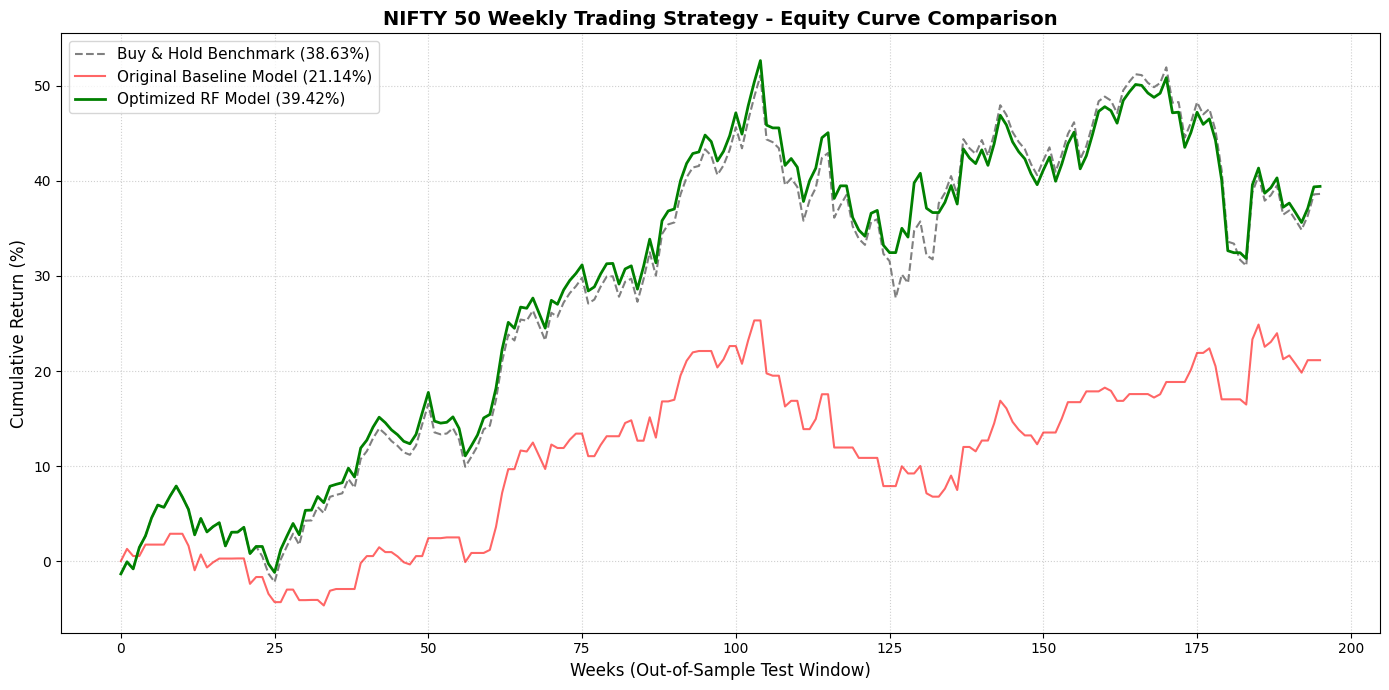

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

# Convert the index to strings or dates if needed for better x-axis representation
plot_index = range(len(test_returns))

# Plot all three paths
plt.plot(plot_index, cum_buy_and_hold * 100, label=f'Buy & Hold Benchmark ({final_bh_pct:.2f}%)', color='gray', linestyle='--')
plt.plot(plot_index, cum_strategy * 100, label=f'Original Baseline Model ({final_strat_pct:.2f}%)', color='red', alpha=0.6)
plt.plot(plot_index, cum_opt_strategy * 100, label=f'Optimized RF Model ({final_opt_strat_pct:.2f}%)', color='green', linewidth=2)

# Styling and labels
plt.title('NIFTY 50 Weekly Trading Strategy - Equity Curve Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Weeks (Out-of-Sample Test Window)', fontsize=12)
plt.ylabel('Cumulative Return (%)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11, loc='upper left')

# Render the final plot
plt.tight_layout()
plt.show()

## 📌 Project Conclusion & Key Takeaways

### 1. Performance Overview
* **Optimized Model Accuracy:** **59.18%** (Out-of-sample directional prediction).
* **Strategy Cumulative Return:** **39.42%** over the 196-week testing window.
* **Benchmark Performance:** Successfully outperformed both the unoptimized baseline model (**21.14%**) and the **NIFTY 50 Buy & Hold** strategy (**38.63%**).

### 2. Core Machine Learning Insight
The turning point in this pipeline was capping the `max_depth` hyperparameter to a maximum of 3. Restricting tree depth intentionally introduced bias to drastically reduce model variance. This architectural constraint prevented the Random Forest from overfitting to short-term market noise, forcing it to capture only highly persistent, structural weekly momentum trends.

### 3. Execution Realities for Live Trading
* **Statistical Edge:** A 59.18% accuracy is a probabilistic edge. It requires long-term adherence over hundreds of weeks to allow the law of large numbers to smooth out temporary drawdown streaks.
* **Compounding Engine:** The backtest assumes 100% reinvestment of weekly profits. Capital cannot be stripped out of the account without breaking the exponential compounding curve that allows the strategy to beat the index.